In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.layers import Conv1D, MaxPool1D
from tensorflow.keras.optimizers import Adam
print(tf.__version__)

2.12.0


In [ ]:
import pandas as pd
import numpy as np
import  seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Deep Learning/creditcard.csv')
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
data.shape

(284807, 31)

In [ ]:
data['Class'].value_counts()

0    284315
1       492
Name: Class, dtype: int64

In [ ]:
non_fraud = data[data['Class']==0]
fraud = data[data['Class']==1]

In [ ]:
non_fraud.shape, fraud.shape

((284315, 31), (492, 31))

In [ ]:
non_fraud = non_fraud.sample(fraud.shape[0])
non_fraud.shape

(492, 31)

In [ ]:
data = fraud.append(non_fraud, ignore_index=True)
data

<ipython-input-83-6b154fc43f9c>:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  data = fraud.append(non_fraud, ignore_index=True)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,406.0,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.00,1
1,472.0,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,...,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.00,1
2,4462.0,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,...,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,239.93,1
3,6986.0,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,...,0.573574,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,59.00,1
4,7519.0,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,...,-0.379068,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,1.00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
979,69999.0,1.158519,0.015627,0.732344,0.983343,-0.855541,-1.015518,-0.004221,-0.159122,0.467238,...,-0.189025,-0.419986,0.065919,0.955890,0.366985,0.234722,-0.026979,0.021007,25.41,0
980,156266.0,1.924443,-0.972428,-0.127755,0.534560,-1.093009,0.275374,-1.144219,0.239476,-0.063387,...,-0.346630,-0.562917,0.308194,-0.590149,-0.508126,-0.817793,0.079275,-0.024887,57.22,0
981,80176.0,1.301367,-0.627534,0.181191,-0.727585,-0.961593,-0.846016,-0.449599,-0.121268,-1.078614,...,0.283057,0.595015,-0.157035,0.364256,0.567635,-0.136921,-0.021367,0.006607,53.55,0
982,123916.0,-1.216797,-0.302078,-0.627510,0.001109,1.615061,-0.780015,0.905488,-0.260018,0.204718,...,0.092118,0.735566,0.627058,0.444889,-0.493808,0.263267,-0.057344,0.486076,60.00,0


In [ ]:
data['Class'].value_counts()

1    492
0    492
Name: Class, dtype: int64

In [ ]:
X = data.drop('Class', axis = 1)
y = data['Class']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0, stratify = y)

In [ ]:
X_train.shape, X_test.shape

((787, 30), (197, 30))

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

In [ ]:
X_train.shape

(787, 30)

In [ ]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [ ]:
X_train.shape, X_test.shape

((787, 30, 1), (197, 30, 1))

In [ ]:
epochs = 20
model = Sequential()
model.add(Conv1D(32, 2, activation='relu', input_shape = X_train[0].shape))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Conv1D(64, 2, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

In [ ]:
model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_8 (Conv1D)           (None, 29, 32)            96        
                                                                 
 batch_normalization_8 (Batc  (None, 29, 32)           128       
 hNormalization)                                                 
                                                                 
 dropout_12 (Dropout)        (None, 29, 32)            0         
                                                                 
 conv1d_9 (Conv1D)           (None, 28, 64)            4160      
                                                                 
 batch_normalization_9 (Batc  (None, 28, 64)           256       
 hNormalization)                                                 
                                                                 
 dropout_13 (Dropout)        (None, 28, 64)           

In [ ]:
model.compile(optimizer=Adam(learning_rate=0.0001), loss = 'binary_crossentropy', metrics=['accuracy'])

In [ ]:
history = model.fit(X_train, y_train, epochs=epochs, validation_data=(X_test, y_test), verbose=1)

Epoch 1/20
25/25 [==============================] - 5s 33ms/step - loss: 0.8804 - accuracy: 0.6429 - val_loss: 0.6235 - val_accuracy: 0.7513
Epoch 2/20
25/25 [==============================] - 0s 18ms/step - loss: 0.5691 - accuracy: 0.7929 - val_loss: 0.5847 - val_accuracy: 0.7614
Epoch 3/20
25/25 [==============================] - 1s 21ms/step - loss: 0.4486 - accuracy: 0.8501 - val_loss: 0.5526 - val_accuracy: 0.7817
Epoch 4/20
25/25 [==============================] - 0s 12ms/step - loss: 0.3727 - accuracy: 0.8564 - val_loss: 0.5131 - val_accuracy: 0.8528
Epoch 5/20
25/25 [==============================] - 0s 12ms/step - loss: 0.3499 - accuracy: 0.8831 - val_loss: 0.4769 - val_accuracy: 0.8782
Epoch 6/20
25/25 [==============================] - 0s 12ms/step - loss: 0.3268 - accuracy: 0.8882 - val_loss: 0.4424 - val_accuracy: 0.8782
Epoch 7/20
25/25 [==============================] - 0s 12ms/step - loss: 0.3196 - accuracy: 0.8844 - val_loss: 0.4060 - val_accuracy: 0.8985
Epoch 8/20
25

In [ ]:
def plot_learningCurve(history, epoch):
  # Plot training & validation accuracy values
  epoch_range = range(1, epoch+1)
  plt.plot(epoch_range, history.history['accuracy'])
  plt.plot(epoch_range, history.history['val_accuracy'])
  plt.title('Model accuracy')
  plt.ylabel('Accuracy')
  plt.xlabel('Epoch')
  plt.legend(['Train', 'Val'], loc='upper left')
  plt.show()

  # Plot training & validation loss values
  plt.plot(epoch_range, history.history['loss'])
  plt.plot(epoch_range, history.history['val_loss'])
  plt.title('Model loss')
  plt.ylabel('Loss')
  plt.xlabel('Epoch')
  plt.legend(['Train', 'Val'], loc='upper left')
  plt.show()

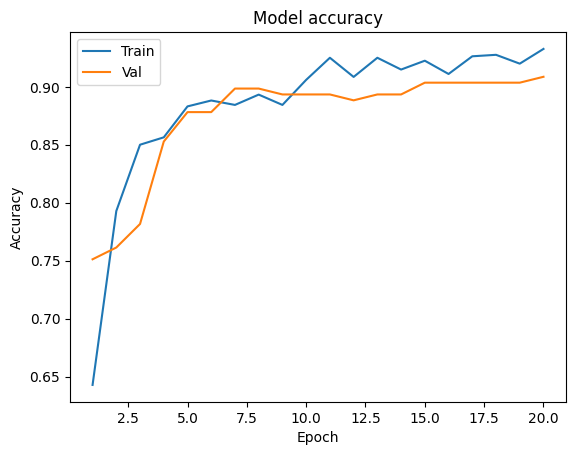

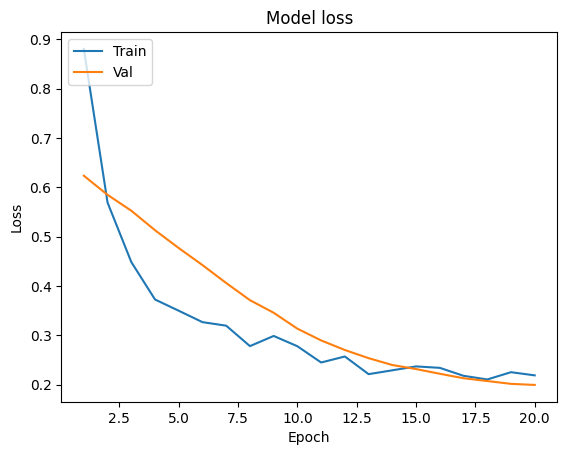

In [ ]:
plot_learningCurve(history, epochs)

Epoch 1/50
25/25 [==============================] - 2s 17ms/step - loss: 0.6165 - accuracy: 0.7611 - val_loss: 0.5817 - val_accuracy: 0.8426
Epoch 2/50
25/25 [==============================] - 0s 7ms/step - loss: 0.4060 - accuracy: 0.8475 - val_loss: 0.5288 - val_accuracy: 0.8477
Epoch 3/50
25/25 [==============================] - 0s 8ms/step - loss: 0.2733 - accuracy: 0.9009 - val_loss: 0.4794 - val_accuracy: 0.8376
Epoch 4/50
25/25 [==============================] - 0s 10ms/step - loss: 0.2767 - accuracy: 0.9085 - val_loss: 0.4420 - val_accuracy: 0.8832
Epoch 5/50
25/25 [==============================] - 0s 9ms/step - loss: 0.2504 - accuracy: 0.9034 - val_loss: 0.3998 - val_accuracy: 0.8731
Epoch 6/50
25/25 [==============================] - 0s 7ms/step - loss: 0.2494 - accuracy: 0.9225 - val_loss: 0.3603 - val_accuracy: 0.8832
Epoch 7/50
25/25 [==============================] - 0s 9ms/step - loss: 0.2400 - accuracy: 0.9250 - val_loss: 0.3334 - val_accuracy: 0.8883
Epoch 8/50
25/25 [

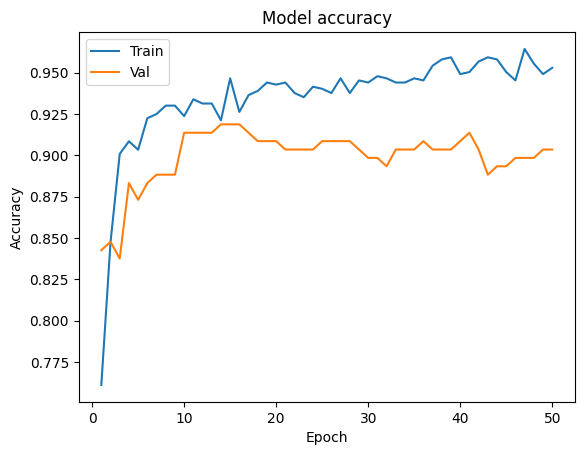

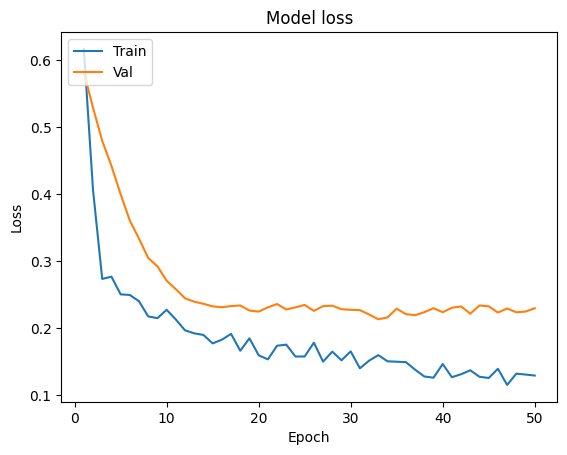

In [ ]:
epochs = 50
model = Sequential()
model.add(Conv1D(32, 2, activation='relu', input_shape = X_train[0].shape))
model.add(BatchNormalization())
model.add(MaxPool1D(2))
model.add(Dropout(0.2))

model.add(Conv1D(64, 2, activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool1D(2))
model.add(Dropout(0.5))

model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer=Adam(lr=0.0001), loss = 'binary_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=epochs, validation_data=(X_test, y_test), verbose=1)
plot_learningCurve(history, epochs)

# **LSTM**

In [ ]:
import numpy as np
import pandas as pd
from keras.models import Sequential
from keras.layers import Dense, LSTM
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from matplotlib import pyplot

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/Deep Learning/creditcard.csv")
# Scale the data
scaler = StandardScaler()
data['Amount'] = scaler.fit_transform(data['Amount'].values.reshape(-1, 1))

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(data.drop(['Class'], axis=1), data['Class'], test_size=0.2, random_state=42)


In [ ]:
X_train.shape[0]

227845

In [ ]:
X_train.shape[1]

30

In [ ]:
np.array(y_train)

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
np.array(X_train).reshape(227845, 30, 1)

array([[[ 1.43352000e+05],
        [ 1.95504092e+00],
        [-3.80782711e-01],
        ...,
        [ 4.51682478e-02],
        [-4.71447917e-02],
        [-3.13288512e-01]],

       [[ 1.17173000e+05],
        [-4.00975239e-01],
        [-6.26942769e-01],
        ...,
        [-3.70468822e-01],
        [-1.44791686e-01],
        [-1.69717237e-01]],

       [[ 1.49565000e+05],
        [ 7.25090164e-02],
        [ 8.20565650e-01],
        ...,
        [ 2.06394866e-01],
        [ 7.02877702e-02],
        [-3.05292340e-01]],

       ...,

       [[ 7.97950000e+04],
        [-1.46608925e-01],
        [ 9.92946123e-01],
        ...,
        [-1.21139194e-01],
        [-1.96195328e-01],
        [-3.37476933e-01]],

       [[ 8.79310000e+04],
        [-2.94863809e+00],
        [ 2.35484929e+00],
        ...,
        [ 4.96912107e-01],
        [ 3.35821632e-01],
        [-3.49231307e-01]],

       [[ 7.63810000e+04],
        [ 1.23317435e+00],
        [-7.84850501e-01],
        ...,
        

In [ ]:
y_train = np.expand_dims(y_train, axis=-1)

In [ ]:
model = Sequential()
model.add(LSTM(units=16, input_shape=(X_train.shape[1], 1), return_sequences=True))
model.add(LSTM(units=8, return_sequences=True))
model.add(Dense(units=1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
model.fit(np.array(X_train), np.array(y_train), epochs=5, batch_size=32)

Epoch 1/5
7121/7121 [==============================] - 200s 28ms/step - loss: 0.0058 - accuracy: 0.9989
Epoch 2/5
7121/7121 [==============================] - 197s 28ms/step - loss: 0.0054 - accuracy: 0.9990
Epoch 3/5
7121/7121 [==============================] - 195s 27ms/step - loss: 0.0051 - accuracy: 0.9991
Epoch 4/5
7121/7121 [==============================] - 196s 28ms/step - loss: 0.0049 - accuracy: 0.9991
Epoch 5/5
7121/7121 [==============================] - 196s 27ms/step - loss: 0.0048 - accuracy: 0.9991


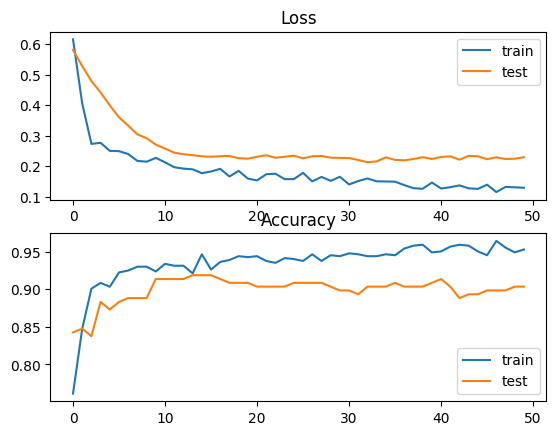

In [ ]:


# plot loss during training
pyplot.subplot(211)
pyplot.title('Loss')
pyplot.plot(history.history['loss'], label='train')
pyplot.plot(history.history['val_loss'], label='test')
pyplot.legend()
# plot accuracy during training
pyplot.subplot(212)
pyplot.title('Accuracy')
pyplot.plot(history.history['accuracy'], label='train')
pyplot.plot(history.history['val_accuracy'], label='test')
pyplot.legend()
pyplot.show()

